Matt Graeve ME 592 HW 1

Problem 2.1

In [6]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 110.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 115.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 90.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [8]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 98.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 80.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install einops

Note: you may need to restart the kernel to use updated packages.


In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from einops import rearrange

In [2]:
transform = transforms.ToTensor()

In [3]:
# Download and load the MNIST training dataset
mnist_data = datasets.MNIST(
    root='.',       # download to current directory
    train=True,     # training set
    download=True,  
    transform=transform
)

In [4]:
# Number of samples we want
num_samples = 1000

In [5]:
# Create a subset of MNIST
subset_data = mnist_data.data[:num_samples]    # shape: [1000, 28, 28]
subset_targets = mnist_data.targets[:num_samples]  # shape: [1000]

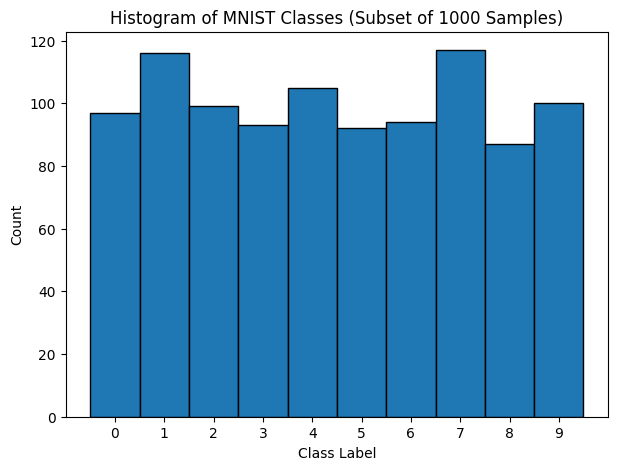

In [6]:
plt.figure(figsize=(7,5))
plt.hist(subset_targets.numpy(), bins=np.arange(11) - 0.5, edgecolor='black')
plt.xticks(range(10))
plt.title("Histogram of MNIST Classes (Subset of 1000 Samples)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

In [7]:
# Add the channel dimension: [1000, 28, 28] -> [1000, 1, 28, 28]
subset_data = subset_data.unsqueeze(1)  # shape is now [1000, 1, 28, 28]

In [8]:
# Rearrange into batches of size 25: [1000, 1, 28, 28] -> [40, 25, 1, 28, 28]
batch_size = 25
batched_data = rearrange(
    subset_data, 
    '(b s) c h w -> b s c h w', 
    s=batch_size
)

In [9]:
# Confirm new shape
print("Batched data shape:", batched_data.shape)

Batched data shape: torch.Size([40, 25, 1, 28, 28])


In [10]:
from mpl_toolkits.mplot3d import Axes3D

In [11]:
# Randomly choose an index
random_idx = np.random.randint(0, num_samples)

In [12]:
# Extract the image and label
random_img = subset_data[random_idx]  # shape: [1, 28, 28]
random_label = subset_targets[random_idx].item()

In [13]:
# Remove the channel dimension to get [28,28]
random_img = random_img.squeeze(0)

In [14]:
# Convert to numpy for plotting
random_img_np = random_img.numpy()

In [15]:
# Set up a meshgrid for x,y coordinates
x = np.arange(random_img_np.shape[1])
y = np.arange(random_img_np.shape[0])
X, Y = np.meshgrid(x, y)

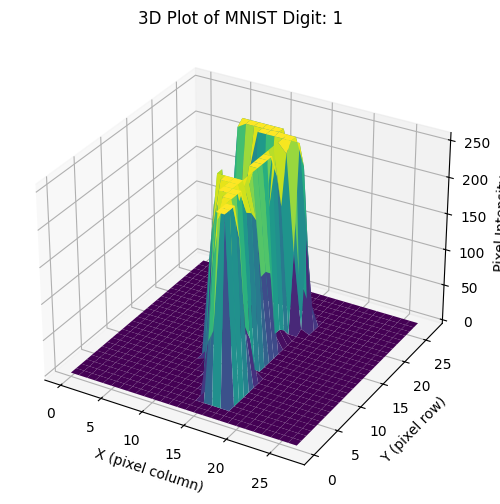

In [16]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, random_img_np, cmap='viridis')

ax.set_title(f"3D Plot of MNIST Digit: {random_label}")
ax.set_xlabel("X (pixel column)")
ax.set_ylabel("Y (pixel row)")
ax.set_zlabel("Pixel Intensity")
plt.show()

Problem 2.2

In [2]:
pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 37.5 MB/s eta 0:00:001m23.6 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [18]:
# Read CSV and parse dates
df = pd.read_csv('energydata_complete.csv', parse_dates=['date'])

In [19]:
# Set the date column as index for convenience
df.set_index('date', inplace=True)

In [20]:
# Check the first few rows
print(df.head())

                     Appliances  lights     T1       RH_1    T2       RH_2  \
date                                                                         
2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

                        T3       RH_3         T4       RH_4  ...         T9  \
date                                                         ...              
2016-01-11 17:00:00  19.79  44.730000  19.000000  45.566667  ...  17.033333   
2016-01-11 17:10:00  19.79  44.790000  19.000000  45.992500  ...  17.066667   
2016-01-11 17:20:00  19.79  44.933333  18.926667  45.890000  ...  17.000000   
2016-01-11 17:30:00  19.79  45.000000  18.890000  45.72333

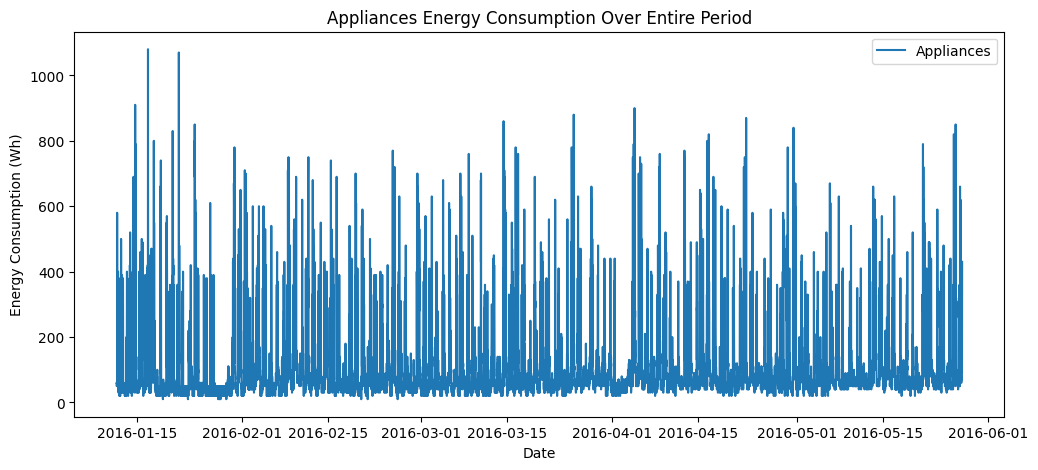

In [21]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Appliances'], label='Appliances')
plt.title('Appliances Energy Consumption Over Entire Period')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (Wh)')
plt.legend()
plt.show()

In [22]:
one_week = df.loc['2016-01-18':'2016-01-24']

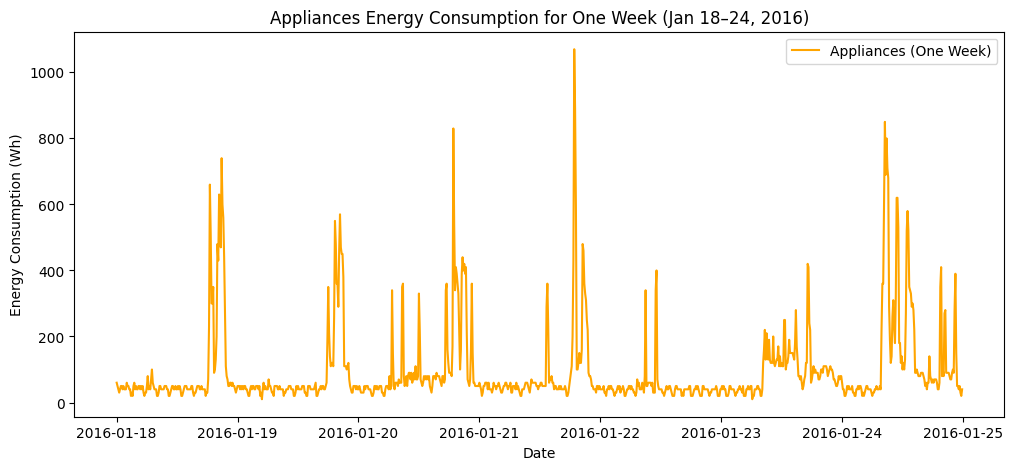

In [23]:
plt.figure(figsize=(12, 5))
plt.plot(one_week.index, one_week['Appliances'], color='orange', label='Appliances (One Week)')
plt.title('Appliances Energy Consumption for One Week (Jan 18–24, 2016)')
plt.xlabel('Date')
plt.ylabel('Energy Consumption (Wh)')
plt.legend()
plt.show()

In [24]:
# Filter one week (same week as above, e.g. 2016-01-18 to 2016-01-24)
one_week_hourly = df.loc['2016-01-18':'2016-01-24'].resample('H').mean()

/tmp/ipykernel_7765/3054767973.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  one_week_hourly = df.loc['2016-01-18':'2016-01-24'].resample('H').mean()


In [25]:
# Extract day of week and hour as separate columns
one_week_hourly['DayOfWeek'] = one_week_hourly.index.day_name()  # or .weekday for numeric
one_week_hourly['Hour'] = one_week_hourly.index.hour

In [26]:
# Pivot to get a matrix of Hour vs. DayOfWeek
# Order the days if desired (e.g. Monday -> Sunday). 
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

In [27]:
pivot_data = one_week_hourly.pivot_table(
    values='Appliances',
    index='Hour',
    columns='DayOfWeek',
    aggfunc=np.mean
)

/tmp/ipykernel_7765/3033633417.py:1: FutureWarning: The provided callable <function mean at 0x7c62fbfdb370> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pivot_data = one_week_hourly.pivot_table(


In [28]:
# Reorder columns to day_order
pivot_data = pivot_data[day_order]

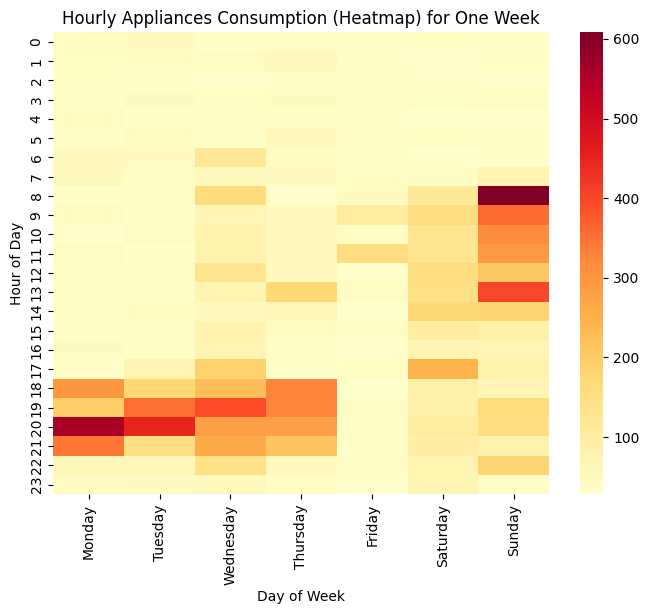

In [29]:
# (d) Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(pivot_data, cmap='YlOrRd')  # choose a colormap you like
plt.title('Hourly Appliances Consumption (Heatmap) for One Week')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.show()

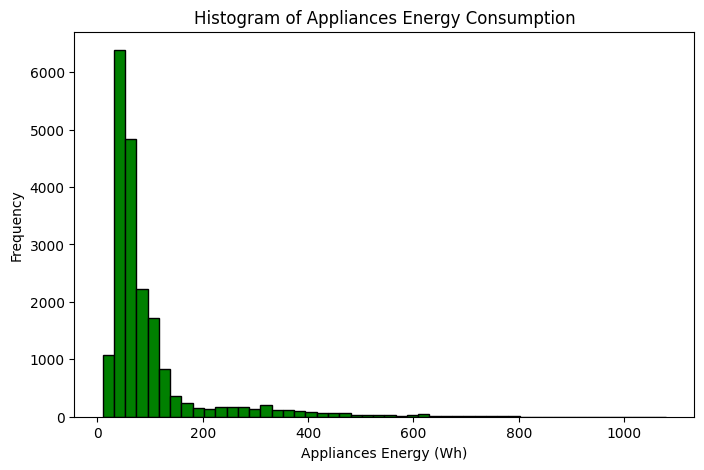

In [30]:
# Histogram of Energy Consumption of Appliances
plt.figure(figsize=(8,5))
plt.hist(df['Appliances'], bins=50, color='green', edgecolor='black')
plt.title('Histogram of Appliances Energy Consumption')
plt.xlabel('Appliances Energy (Wh)')
plt.ylabel('Frequency')
plt.show()

In [31]:
df['Hour'] = df.index.hour
df['Minute'] = df.index.minute
df['Second'] = df.index.second

df['NSM'] = df['Hour']*3600 + df['Minute']*60 + df['Second']

In [32]:
plt.figure(figsize=(8, 5))
# Pick one random day or a short range to avoid clutter
one_day = df.loc['2016-01-18']

<Figure size 800x500 with 0 Axes>

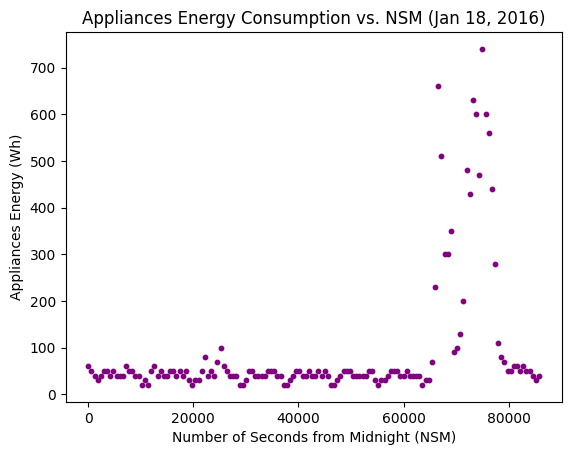

In [33]:
plt.scatter(one_day['NSM'], one_day['Appliances'], s=10, color='purple')
plt.title('Appliances Energy Consumption vs. NSM (Jan 18, 2016)')
plt.xlabel('Number of Seconds from Midnight (NSM)')
plt.ylabel('Appliances Energy (Wh)')
plt.show()

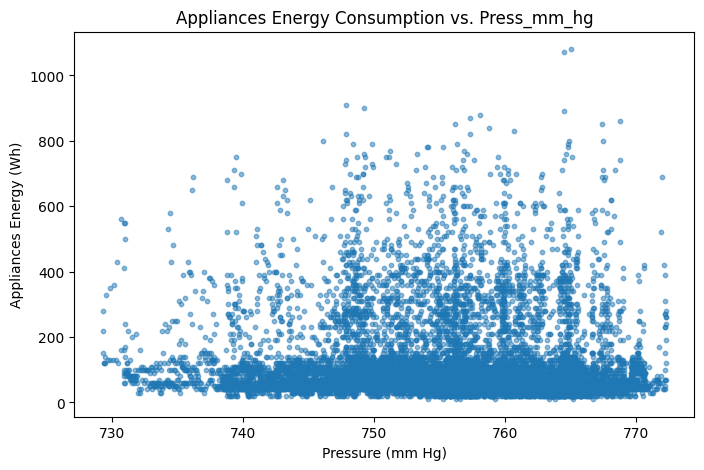

In [34]:
plt.figure(figsize=(8,5))
plt.scatter(df['Press_mm_hg'], df['Appliances'], s=10, alpha=0.5)
plt.title('Appliances Energy Consumption vs. Press_mm_hg')
plt.xlabel('Pressure (mm Hg)')
plt.ylabel('Appliances Energy (Wh)')
plt.show()

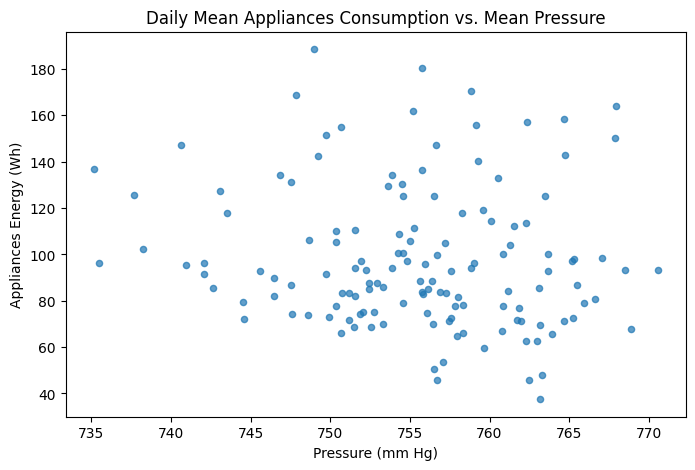

In [35]:
daily_df = df.resample('D').mean()
plt.figure(figsize=(8,5))
plt.scatter(daily_df['Press_mm_hg'], daily_df['Appliances'], s=20, alpha=0.7)
plt.title('Daily Mean Appliances Consumption vs. Mean Pressure')
plt.xlabel('Pressure (mm Hg)')
plt.ylabel('Appliances Energy (Wh)')
plt.show()

NSM has a natural correlation with the appliance energy because people are more likely to use appliances during the day. THis is why there is a spike
in the NSM versus Appliance energy consumption graph in the middle of the day. Additionally, the pressure versus appliance energy consumption data showss that as the pressure increases, the appliance energy increases as well. This could be ebcause higher pressures indicate weather changes that could cause HVAC systems to work harder. 

Problem 2.3

In [28]:
pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 MB 163.8 MB/s eta 0:00:00m eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [36]:
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew

In [37]:
data_file = 'airfoil_self_noise.dat'
df = pd.read_csv(data_file, sep='\t', header=None)

In [38]:
# Label each column according to the problem statement
df.columns = [
    "Frequency_Hz", 
    "Angle_of_Attack_deg", 
    "Chord_Length_m", 
    "Free_Stream_Velocity_m_s", 
    "Suction_Side_Displacement_Thickness_m", 
    "Scaled_Sound_Pressure_Level_dB"
]

In [39]:
# Mean (per column)
mean_values = df.mean()

In [40]:
# Variance or Standard Deviation (per column)
variance_values = df.var()
std_values = df.std()

In [41]:
# Median (per column)
median_values = df.median()

In [42]:
# Kurtosis (per column)
# By default, `kurtosis()` in scipy.stats returns Fisher’s definition (excess kurtosis).
kurtosis_values = kurtosis(df, fisher=True)

In [43]:
# Skewness (per column)
skewness_values = skew(df)

In [44]:
# Range (per column): max - min
range_values = df.max() - df.min()

In [45]:
print("==== Descriptive Statistics ====")
print("Mean:\n", mean_values, "\n")
print("Variance:\n", variance_values, "\n")
print("Standard Deviation:\n", std_values, "\n")
print("Median:\n", median_values, "\n")
print("Kurtosis (excess):\n", kurtosis_values, "\n")
print("Skewness:\n", skewness_values, "\n")
print("Range:\n", range_values, "\n")

==== Descriptive Statistics ====
Mean:
 Frequency_Hz                             2886.380572
Angle_of_Attack_deg                         6.782302
Chord_Length_m                              0.136548
Free_Stream_Velocity_m_s                   50.860745
Suction_Side_Displacement_Thickness_m       0.011140
Scaled_Sound_Pressure_Level_dB            124.835943
dtype: float64 

Variance:
 Frequency_Hz                             9.938717e+06
Angle_of_Attack_deg                      3.502424e+01
Chord_Length_m                           8.749868e-03
Free_Stream_Velocity_m_s                 2.425116e+02
Suction_Side_Displacement_Thickness_m    1.729287e-04
Scaled_Sound_Pressure_Level_dB           4.759146e+01
dtype: float64 

Standard Deviation:
 Frequency_Hz                             3152.573137
Angle_of_Attack_deg                         5.918128
Chord_Length_m                              0.093541
Free_Stream_Velocity_m_s                   15.572784
Suction_Side_Displacement_Thickness_m   